# Time-of-Day Shuffle Test

**Question:** Is the TimeOfDay strategy's improvement over the fixed baseline real, or just noise from having more flexible thresholds?

**Method:** Randomly permute the minute-of-day spread ratios 100 times. Each shuffle breaks the real time-of-day pattern while preserving the same *distribution* of threshold adjustments. If the real (unshuffled) result doesn't stand out from the shuffled distribution, the improvement is noise.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.config import DEFAULT_CONFIG
from utils.preprocessing import load_all_stocks, train_test_split
from utils.strategy import (
    OIThresholdStrategy, TimeOfDayOIThresholdStrategy,
    fit_strategy, precompute_minute_data, _fit_params_for_precomputed,
)
from utils.evaluation import evaluate_both_sides

config = DEFAULT_CONFIG.copy()
data, frames, archetypes = load_all_stocks(config)
train_data, test_data = train_test_split(data, config)

print(f"Train: {train_data['minute_start'].nunique()} min, Test: {test_data['minute_start'].nunique()} min")

Train: 189 min, Test: 81 min


## Run Baselines (real fixed + real TimeOfDay)

In [2]:
# Fixed baseline
fixed_fitted, _ = fit_strategy(OIThresholdStrategy, train_data, config)
fixed_test = evaluate_both_sides(OIThresholdStrategy, test_data, fixed_fitted)

# Real TimeOfDay
tod_fitted, tod_details = TimeOfDayOIThresholdStrategy.fit_params(train_data, config)
tod_test = evaluate_both_sides(TimeOfDayOIThresholdStrategy, test_data, tod_fitted)

# Report
for arch in ['penny', 'wide']:
    med_spr = test_data[test_data['archetype'] == arch]['spread'].median()
    fixed_imp = fixed_test[fixed_test['archetype'] == arch]['strategy'].mean() / med_spr
    tod_imp = tod_test[tod_test['archetype'] == arch]['strategy'].mean() / med_spr
    print(f"{arch.title():6s}: Fixed = {fixed_imp:+.4f},  TimeOfDay = {tod_imp:+.4f},  diff = {tod_imp - fixed_imp:+.4f} spread units")

Penny : Fixed = +0.5634,  TimeOfDay = +0.6097,  diff = +0.0463 spread units
Wide  : Fixed = +0.2659,  TimeOfDay = +0.1803,  diff = -0.0856 spread units


## Shuffle Test (100 permutations)

For each shuffle: take the real spread ratios per minute-of-day, randomly permute which ratio maps to which minute, rebuild the fitted params with the shuffled mapping, and evaluate on the test set.

In [3]:
N_SHUFFLES = 100
rng = np.random.default_rng(42)

cls = TimeOfDayOIThresholdStrategy
smooth_size = config.get('smooth_size', 3)

# Pre-compute base params and spread profiles ONCE (the expensive part)
base_cache = {}
for arch in ['penny', 'wide']:
    arch_train = train_data[train_data['archetype'] == arch].copy()
    pre = precompute_minute_data(arch_train, 'oi')
    if len(pre) < 5:
        continue

    base_params, _ = _fit_params_for_precomputed(cls, pre, arch, 'oi', smooth_size)

    minute_profile = (
        arch_train.assign(minute_of_day=(arch_train['minute_start'] // 60).astype(int))
        .groupby('minute_of_day')
        .agg(avg_spread=('spread', 'mean'))
        .reset_index()
        .sort_values('minute_of_day')
    )
    spread_curve = uniform_filter1d(minute_profile['avg_spread'].to_numpy(dtype=float), smooth_size)
    spread_ratio = spread_curve / spread_curve.mean()
    minutes = minute_profile['minute_of_day'].to_numpy(dtype=int)
    minute_grid = np.arange(minutes.min(), minutes.max() + 1)
    minute_ratio = np.interp(minute_grid, minutes, spread_ratio)

    base_cache[arch] = {
        'base_params': base_params,
        'minute_grid': minute_grid,
        'minute_ratio': minute_ratio,
    }

print("Base params and profiles cached.")
for arch, c in base_cache.items():
    print(f"  {arch}: base_imb={c['base_params']['theta_imb']:.4f}, "
          f"base_spread={c['base_params']['theta_spread']:.4f}, "
          f"{len(c['minute_grid'])} minutes")


def build_shuffled_fitted(shuffle=True):
    """Build fitted params with optionally shuffled spread ratios. No grid search."""
    fitted = {}
    for arch, c in base_cache.items():
        minute_grid = c['minute_grid']
        ratio_arr = rng.permutation(c['minute_ratio']) if shuffle else c['minute_ratio']
        bp = c['base_params']

        for minute_of_day, ratio in zip(minute_grid, ratio_arr):
            theta_spread = float(bp['theta_spread'] * (ratio ** cls.spread_power))
            theta_imb = float(np.clip(
                bp['theta_imb'] + cls.imb_sensitivity * (ratio - 1.0),
                cls.min_theta_imb, cls.max_theta_imb,
            ))
            fitted[(arch, int(minute_of_day))] = {
                'theta_imb': theta_imb,
                'theta_spread': theta_spread,
            }
    return fitted


# Run shuffles (fast — no grid search, just eval)
shuffle_results = {'penny': [], 'wide': []}

for i in range(N_SHUFFLES):
    if (i + 1) % 20 == 0:
        print(f"  Shuffle {i + 1}/{N_SHUFFLES}...")
    shuffled_fitted = build_shuffled_fitted(shuffle=True)
    shuffled_test = evaluate_both_sides(
        TimeOfDayOIThresholdStrategy, test_data, shuffled_fitted
    )
    for arch in ['penny', 'wide']:
        sub = shuffled_test[shuffled_test['archetype'] == arch]
        med_spr = test_data[test_data['archetype'] == arch]['spread'].median()
        shuffle_results[arch].append(sub['strategy'].mean() / med_spr)

print("Done.")

Base params and profiles cached.
  penny: base_imb=0.9500, base_spread=0.0116, 189 minutes
  wide: base_imb=0.5200, base_spread=0.1566, 189 minutes
  Shuffle 20/100...
  Shuffle 40/100...
  Shuffle 60/100...
  Shuffle 80/100...
  Shuffle 100/100...
Done.


## Results

If the red line (real TimeOfDay) is well within the shuffled distribution, the time-of-day mapping adds no value — any random mapping does equally well.

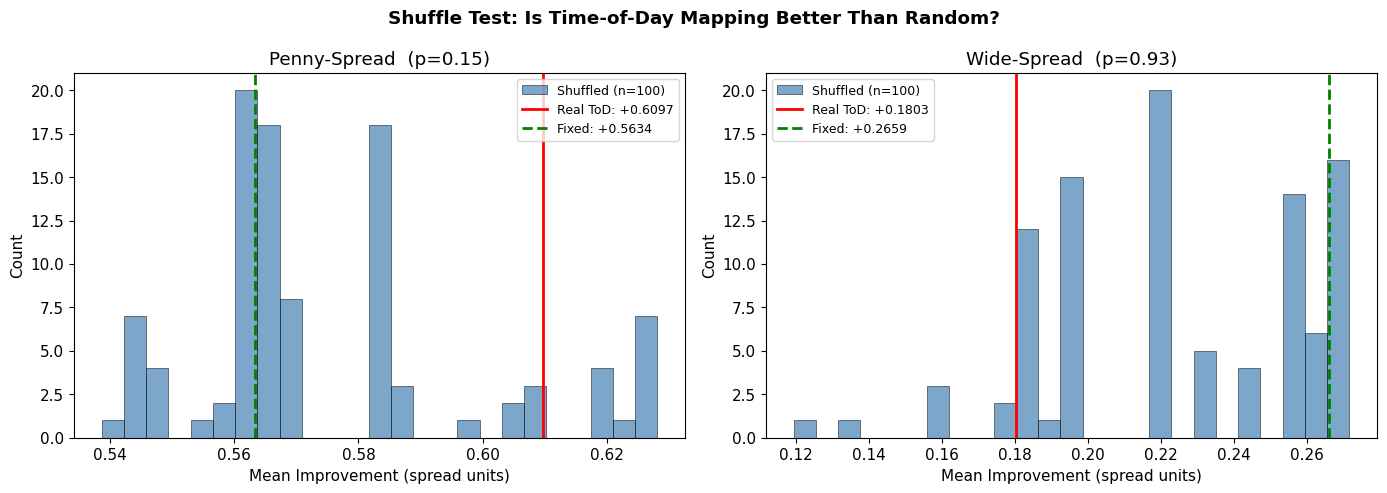


Summary:
  Penny:
    Real ToD:      +0.6097 spread units
    Shuffled mean: +0.5758 (std=0.0234)
    p-value:       0.15 (15% of shuffles beat real)
    Verdict:       NOT SIGNIFICANT
  Wide:
    Real ToD:      +0.1803 spread units
    Shuffled mean: +0.2249 (std=0.0362)
    p-value:       0.93 (93% of shuffles beat real)
    Verdict:       NOT SIGNIFICANT


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arch in zip(axes, ['penny', 'wide']):
    med_spr = test_data[test_data['archetype'] == arch]['spread'].median()

    # Real values
    fixed_imp = fixed_test[fixed_test['archetype'] == arch]['strategy'].mean() / med_spr
    tod_imp = tod_test[tod_test['archetype'] == arch]['strategy'].mean() / med_spr

    # Shuffle distribution
    shuffled = np.array(shuffle_results[arch])

    ax.hist(shuffled, bins=25, alpha=0.7, color='steelblue', edgecolor='black',
            linewidth=0.5, label=f'Shuffled (n={N_SHUFFLES})')
    ax.axvline(tod_imp, color='red', lw=2, ls='-', label=f'Real ToD: {tod_imp:+.4f}')
    ax.axvline(fixed_imp, color='green', lw=2, ls='--', label=f'Fixed: {fixed_imp:+.4f}')

    # p-value: fraction of shuffles that beat the real result
    p_val = (shuffled >= tod_imp).mean()
    ax.set_title(f'{arch.title()}-Spread  (p={p_val:.2f})')
    ax.set_xlabel('Mean Improvement (spread units)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('Shuffle Test: Is Time-of-Day Mapping Better Than Random?', fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print("\nSummary:")
for arch in ['penny', 'wide']:
    med_spr = test_data[test_data['archetype'] == arch]['spread'].median()
    tod_imp = tod_test[tod_test['archetype'] == arch]['strategy'].mean() / med_spr
    shuffled = np.array(shuffle_results[arch])
    p_val = (shuffled >= tod_imp).mean()
    print(f"  {arch.title()}:")
    print(f"    Real ToD:      {tod_imp:+.4f} spread units")
    print(f"    Shuffled mean: {shuffled.mean():+.4f} (std={shuffled.std():.4f})")
    print(f"    p-value:       {p_val:.2f} ({int(p_val*100)}% of shuffles beat real)")
    print(f"    Verdict:       {'SIGNIFICANT' if p_val < 0.05 else 'NOT SIGNIFICANT'}")